# Does question wording shape survey responses?

**Author** : Palatine Rigaut

**Date** : November 2025

## 1. Library import

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg

## 2. Data import

In [3]:
df_raw = pd.read_csv("Big Five Personality Test Dataset.csv", sep="\t")
display(df_raw)

,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015336,4.0,2.0,4.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,...,2018-11-08 12:04:58,1920.0,1080.0,3.0,160.0,10,2,US,39.9883,-75.2208
1015337,4.0,3.0,4.0,3.0,3.0,3.0,4.0,4.0,3.0,3.0,...,2018-11-08 12:07:18,1920.0,1080.0,3.0,122.0,7,1,US,38.0,-97.0
1015338,4.0,2.0,4.0,3.0,5.0,1.0,4.0,2.0,4.0,4.0,...,2018-11-08 12:07:49,1920.0,1080.0,2.0,135.0,12,6,US,36.1473,-86.777
1015339,2.0,4.0,3.0,4.0,2.0,2.0,1.0,4.0,2.0,4.0,...,2018-11-08 12:08:34,1920.0,1080.0,6.0,212.0,8,1,US,34.1067,-117.8067


In [4]:
df_codebook = pd.read_csv("Cleaned Codebook.txt", sep="\t", names=["item", "item_statement"])
display(df_codebook)

,item,item_statement
0,EXT1,I am the life of the party.
1,EXT2,I don't talk a lot.
2,EXT3,I feel comfortable around people.
3,EXT4,I keep in the background.
4,EXT5,I start conversations.
5,EXT6,I have little to say.
6,EXT7,I talk to a lot of different people at parties.
7,EXT8,I don't like to draw attention to myself.
8,EXT9,I don't mind being the center of attention.
9,EXT10,I am quiet around strangers.


## 3. Derived variable construction: wording classification (affirmative / negative)

In [42]:
negative_items = {"EXT2", "EXT8", "EXT9", "AGR5", "AGR7", "OPN4", "OPN6"}

df_codebook["wording"] = df_codebook["item"].apply(
    lambda x: "Negative" if x in negative_items else "Affirmative"
)

display(df_codebook)

,item,item_statement,wording
0,EXT1,I am the life of the party.,Affirmative
1,EXT2,I don't talk a lot.,Negative
2,EXT3,I feel comfortable around people.,Affirmative
3,EXT4,I keep in the background.,Affirmative
4,EXT5,I start conversations.,Affirmative
5,EXT6,I have little to say.,Affirmative
6,EXT7,I talk to a lot of different people at parties.,Affirmative
7,EXT8,I don't like to draw attention to myself.,Negative
8,EXT9,I don't mind being the center of attention.,Negative
9,EXT10,I am quiet around strangers.,Affirmative


## 4. Data manipulation

### 4.1. Relevant data selection

In [43]:
item_cols = df_raw.loc[:, "EXT1":"OPN10"].columns

### 4.2. Transformation from wide to long format

In [44]:
df_long = df_raw.melt(
    value_vars=item_cols,
    var_name="item",
    value_name="rating"
)
display(df_long)

,item,rating
0,EXT1,4.0
1,EXT1,3.0
2,EXT1,2.0
3,EXT1,2.0
4,EXT1,3.0
...,...,...
50767045,OPN10,4.0
50767046,OPN10,4.0
50767047,OPN10,5.0
50767048,OPN10,3.0


## 5. Dataset merge and final dataset

### 5.1. Merge responses with codebook

In [57]:
df_merged = df_long.merge(
    df_codebook[["item", "item_statement", "wording"]],
    on="item",
    how="left"
)

### 5.2. Final dataset (columns in the correct order)

In [47]:
df = df_merged[["item", "item_statement", "wording", "rating"]]
display(df)

,item,item_statement,wording,rating
0,EXT1,I am the life of the party.,Affirmative,4.0
1,EXT1,I am the life of the party.,Affirmative,3.0
2,EXT1,I am the life of the party.,Affirmative,2.0
3,EXT1,I am the life of the party.,Affirmative,2.0
4,EXT1,I am the life of the party.,Affirmative,3.0
...,...,...,...,...
50767045,OPN10,I am full of ideas.,Affirmative,4.0
50767046,OPN10,I am full of ideas.,Affirmative,4.0
50767047,OPN10,I am full of ideas.,Affirmative,5.0
50767048,OPN10,I am full of ideas.,Affirmative,3.0


## 6. Data description

### 6.1. Visual elements

In [51]:
likert_palette = [
    "#8B1A1A",
    "#CD5C5C",
    "#C0C0C0",
    "#7FBF7F",
    "#2E8B57"
]

labels = [
    "Strongly\ndisagree",
    "Disagree",
    "Neutral",
    "Agree",
    "Strongly\nagree",
]

wording_palette = {
    "#B0B0B0",
    "#202020"
}

### 6.2. Precompute frequencies (for performance)

In [53]:
# Counting responses 1–5
count_rating = (
    df[df["rating"] > 0]["rating"]
    .value_counts()
    .sort_index()
)

# Counting affirmative/negative items
count_wording_items = (
    df_codebook["wording"]
    .value_counts()
    .reindex(["Affirmative", "Negative"])
)

### 6.3. Figure creation

/var/folders/4h/l2qwrhwd5rn1fq7txjbb0mhw0000gn/T/ipykernel_73483/297487699.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/4h/l2qwrhwd5rn1fq7txjbb0mhw0000gn/T/ipykernel_73483/297487699.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


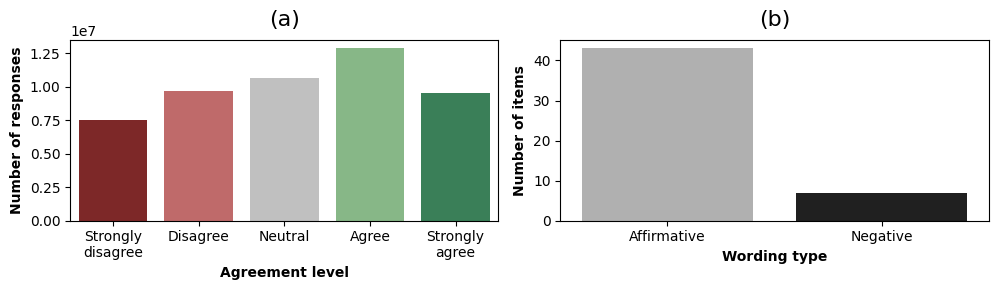

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# ---------------------------------------------------------
# a) Distribution of responses on the Likert scale
# ---------------------------------------------------------
y_counts = [count_rating.get(x, 0) for x in [1.0, 2.0, 3.0, 4.0, 5.0]]

sns.barplot(
    x=labels,
    y=y_counts,
    ax=axes[0],
    palette=likert_palette,
)

axes[0].set_xlabel("Agreement level", fontweight="bold")
axes[0].set_ylabel("Number of responses", fontweight="bold")
axes[0].set_title("(a)", loc="center", fontsize=16, pad=10)

# ---------------------------------------------------------
# b) Distribution of items wording (affirmative / negative)
# ---------------------------------------------------------
sns.barplot(
    x=count_wording_items.index,
    y=count_wording_items.values,
    ax=axes[1],
    palette=wording_palette,
)

axes[1].set_xlabel("Wording type", fontweight="bold")
axes[1].set_ylabel("Number of items", fontweight="bold")
axes[1].set_title("(b)", loc="center", fontsize=16, pad=10)

plt.tight_layout()
plt.show()

## 7. Bivariate analysis

### 7.1. Data preparation for the test

In [71]:
ratings = pd.to_numeric(df["rating"], errors="coerce")

mask = ratings.between(1, 5)
df = df[mask].copy()
ratings = ratings[mask]

df["rating"] = ratings.astype(int)

rating_map = {
    1: "Strongly disagree",
    2: "Disagree",
    3: "Neutral",
    4: "Agree",
    5: "Strongly agree",
}

df["rating_label"] = df["rating"].map(rating_map)

### 7.2. Visualization

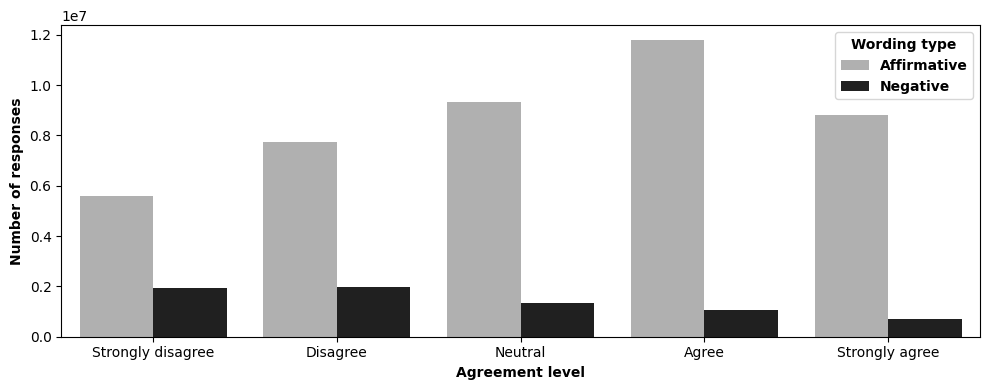

In [78]:
order_labels = [
    "Strongly disagree",
    "Disagree",
    "Neutral",
    "Agree",
    "Strongly agree"
]

plt.figure(figsize=(10,4))
sns.countplot(
    data=df,
    x="rating_label",
    hue="wording",
    order=order_labels,
    palette=wording_palette
)

plt.xlabel("Agreement level", fontweight="bold")
plt.ylabel("Number of responses", fontweight="bold")

leg = plt.legend(
    title="Wording type",
    labels=["Affirmative", "Negative"]
)

leg.get_title().set_fontweight("bold")

for text in leg.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()
plt.show()

### 7.3. Statistical test (independent samples t-test)

In [ ]:
# Average agreement rating for each wording group

mu_aff = df[df["wording"] == "Affirmative"]["rating"].mean()
mu_neg = df[df["wording"] == "Negative"]["rating"].mean()

mu_aff, mu_neg

(np.float64(3.2429077453901454), np.float64(2.5184909035625673))

In [ ]:
# T-test

group_aff = df[df["wording"] == "Affirmative"]["rating"]
group_neg = df[df["wording"] == "Negative"]["rating"]

pg.ttest(x=group_aff, y=group_neg)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1366.769875,9.530494e+06,two-sided,0.0,"[0.72, 0.73]",0.552126,inf,1.0
